In [1]:
!pip install opendatasets

import opendatasets as od

od.download("https://www.kaggle.com/balabaskar/tom-and-jerry-image-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: asmaa
Your Kaggle Key: ··········
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification


100%|██████████| 435M/435M [00:04<00:00, 91.4MB/s]


In [2]:
import os

base = "/content/tom-and-jerry-image-classification/tom_and_jerry/tom_and_jerry"

for folder in os.listdir(base):
    folder_path = os.path.join(base, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")

jerry: 1240 images
tom_jerry_1: 780 images
tom_jerry_0: 1528 images
tom: 1930 images


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_height, img_width = 128, 128
batch_size = 32

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=90,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [9]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
data_dir = '/content/tom-and-jerry-image-classification/tom_and_jerry/tom_and_jerry'

# Assuming your data is split into 'train' and 'validation' (or 'test') subdirectories within data_dir
# If not, we might need to adjust this to use a single directory and split later.

# train_generator = train_datagen.flow_from_directory(
#     os.path.join(data_dir, 'train'),  # Path to your training data
#     target_size=(img_height, img_width),
#     batch_size=batch_size,
#     class_mode='categorical' # or 'binary' if only two classes
# )

# validation_generator = val_datagen.flow_from_directory(
#     os.path.join(data_dir, 'validation'), # Path to your validation data
#     target_size=(img_height, img_width),
#     batch_size=batch_size,
#     class_mode='categorical'
# )

In [10]:
import tensorflow as tf

# Define seed for reproducibility
SEED = 42

# Create training and validation datasets using image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # Use 20% of data for validation
    subset='training',
    seed=SEED,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical' # Since you have multiple classes (tom, jerry, etc.)
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

# Get class names from the dataset
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5478 files belonging to 4 classes.
Using 4383 files for training.
Found 5478 files belonging to 4 classes.
Using 1095 files for validation.
Classes found: ['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1']


In [11]:
# Rescaling layer (normalize pixel values to [0, 1])
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply the normalization to both datasets
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Data Augmentation layers (based on the previously defined ImageDataGenerator parameters)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), # horizontal_flip=True
    tf.keras.layers.RandomRotation(0.2),      # rotation_range=20 degrees (approx 0.2 radians)
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2), # zoom_range=0.2
    # width_shift_range and height_shift_range can be combined into RandomTranslation
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2, fill_mode='nearest'),
    # Note: shear_range is not directly available as a simple Keras preprocessing layer.
    # For shear, a custom layer or more advanced affine transform would be needed.
])

# Apply augmentation only to the training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                        num_parallel_calls=AUTOTUNE)

print("Datasets (train_ds, val_ds) created and configured with augmentation.")
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

Datasets (train_ds, val_ds) created and configured with augmentation.
Number of training batches: 137
Number of validation batches: 35


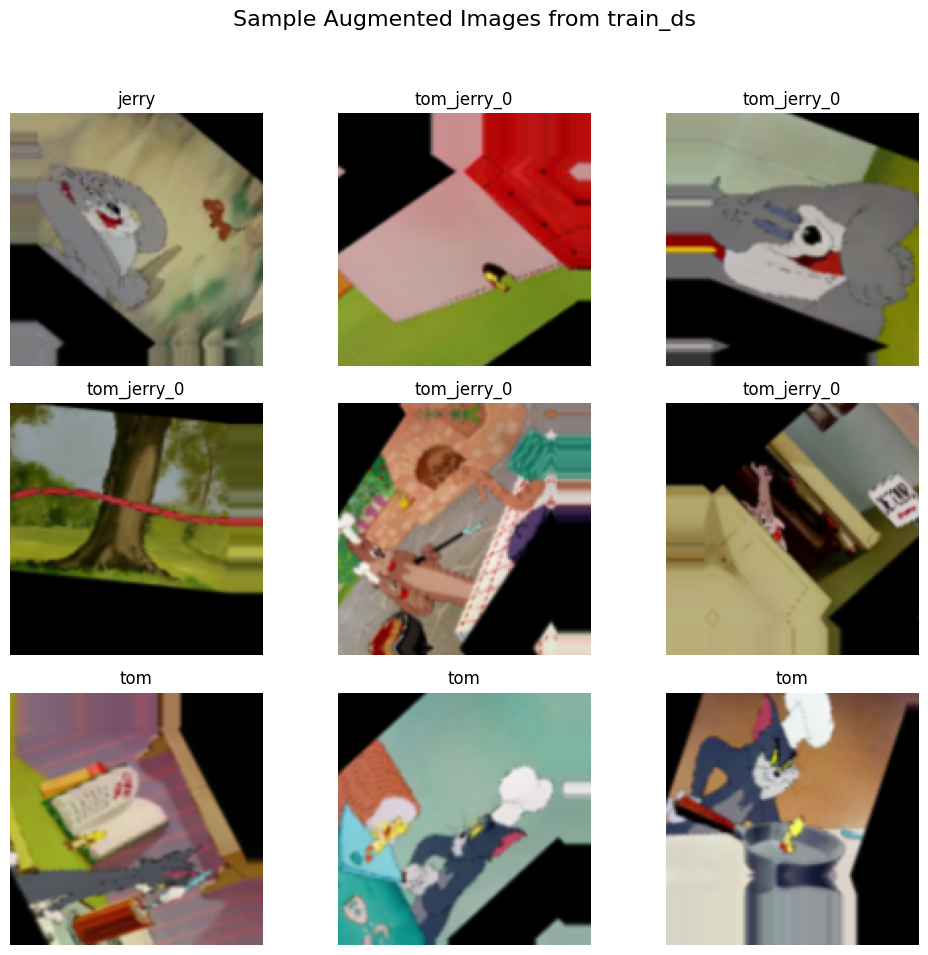

In [18]:
import matplotlib.pyplot as plt

# Get one batch of augmented images and labels from the training dataset
for images, labels in train_ds.take(1):
    augmented_images_batch = images
    augmented_labels_batch = labels

# class_names was already defined from the original dataset creation, no need to re-fetch
# class_names = train_ds.class_names # Removed this line

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # Unnormalize the image for display (if normalization was 1./255)
    plt.imshow(augmented_images_batch[i].numpy())
    # Find the index of the highest probability (which is the predicted class index)
    label_index = tf.argmax(augmented_labels_batch[i])
    plt.title(class_names[label_index])
    plt.axis("off")
plt.suptitle("Sample Augmented Images from train_ds", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [16]:
import os

base = "/content/tom-and-jerry-image-classification/tom_and_jerry/tom_and_jerry"

for folder in os.listdir(base):
    folder_path = os.path.join(base, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")

jerry: 1240 images
tom_jerry_1: 780 images
tom_jerry_0: 1528 images
tom: 1930 images


In [21]:
original_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(img_height, img_width),
    batch_size=1, # Process images individually
    shuffle=False, # Maintain original order
    label_mode='categorical'
)

print(f"Original dataset loaded with {len(original_ds)} images.")

Found 13206 files belonging to 4 classes.
Original dataset loaded with 13206 images.


In [20]:
import numpy as np
from PIL import Image

print("Starting augmentation and saving of images...")

augmented_images_count = 0

for i, (image_batch, label_batch) in enumerate(original_ds):
    image = image_batch[0]
    label = label_batch[0]

    class_index = np.argmax(label.numpy())
    class_name = class_names[class_index]

    target_dir = os.path.join(data_dir, class_name)
    os.makedirs(target_dir, exist_ok=True)

    num_augmentations_per_image = 5
    for j in range(num_augmentations_per_image):

        augmented_image_tensor = data_augmentation(tf.expand_dims(image, 0), training=True)


        augmented_image_np = augmented_image_tensor[0].numpy() * 255
        augmented_image_uint8 = augmented_image_np.astype(np.uint8)

        pil_image = Image.fromarray(augmented_image_uint8)

        filename = f"augmented_{i:05d}_{j}.png"

        pil_image.save(os.path.join(target_dir, filename))
        augmented_images_count += 1

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(original_ds)} original images. Total augmented images generated: {augmented_images_count}")

print(f"Finished augmenting and saving. Total augmented images generated: {augmented_images_count}")


Starting augmentation and saving of images...
Processed 100/5478 original images. Total augmented images generated: 500
Processed 200/5478 original images. Total augmented images generated: 1000
Processed 300/5478 original images. Total augmented images generated: 1500
Processed 400/5478 original images. Total augmented images generated: 2000
Processed 500/5478 original images. Total augmented images generated: 2500
Processed 600/5478 original images. Total augmented images generated: 3000
Processed 700/5478 original images. Total augmented images generated: 3500
Processed 800/5478 original images. Total augmented images generated: 4000
Processed 900/5478 original images. Total augmented images generated: 4500
Processed 1000/5478 original images. Total augmented images generated: 5000
Processed 1100/5478 original images. Total augmented images generated: 5500
Processed 1200/5478 original images. Total augmented images generated: 6000
Processed 1300/5478 original images. Total augmented

KeyboardInterrupt: 